# 3. Modelado con scikit-learn

Entrenamos los 6 modelos que pide el enunciado usando `GridSearchCV` (cv=3, `scoring=\"roc_auc\"`), sin envolverlos en un `Pipeline`, porque los datos ya llegan preprocesados desde la sección 2: matrices dispersas `X_train`/`X_test` con 114 columnas, ya imputadas, escaladas y codificadas, todo ajustado únicamente con el conjunto de entrenamiento.

El hardware real de esta máquina es de 2 núcleos y 7,8 GB de RAM, sin GPU.

Entrenar los 6 modelos completos (`src/model_sklearn.py`) tardó alrededor de 3 horas y 35 minutos en esta máquina, dominado sobre todo por `RandomForestClassifier` (112 minutos) y `LinearSVC` (80 minutos), que explicamos más abajo. Ese tiempo hace poco práctico volver a correr todo el entrenamiento cada vez que se reconstruye este Jupyter Book, así que en este notebook documentamos el código exacto que usamos para entrenar cada modelo (como bloques de referencia, no como celdas que se vuelven a ejecutar), y cargamos los resultados y modelos ya entrenados para construir las tablas, gráficos y diagnósticos de esta sección.

## 3.1. Carga de resultados, modelos y puntajes guardados

In [1]:
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix

results_df = pd.read_csv("../outputs/tables/sklearn_results.csv")
scores_test = pd.read_parquet("../data/sklearn_test_scores.parquet")
models_fitted = joblib.load("../data/sklearn_fitted_models.joblib")
with open("../outputs/tables/hardware_sklearn.json") as f:
    hardware = json.load(f)

y_test = scores_test["default"].values
print("Hardware usado:", hardware)
print(f"Conjunto de prueba: {len(y_test):,} filas, tasa de default = {y_test.mean()*100:.2f}%")
print(f"\nModelos entrenados: {results_df['modelo'].tolist()}")


Hardware usado: {'cores': 2, 'ram_gb': 7.8, 'nota': 'maquina virtual compartida, sin GPU'}
Conjunto de prueba: 452,141 filas, tasa de default = 11.88%

Modelos entrenados: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'GBT_HistGB', 'LinearSVC', 'GaussianNB']


## 3.2. Modelo por modelo: malla de hiperparámetros y razonamiento

A continuación está el código de referencia que usamos en `src/model_sklearn.py` para cada uno de los 6 modelos.

### 3.2.1. Regresión logística

La malla de `C` se define a partir de `n_train` (1.808.560 filas), siguiendo la convención de que `C = 1/(alpha·n)` en scikit-learn equivale al parámetro de regularización `alpha` de otras librerías. Usamos tres órdenes de magnitud de `alpha` (1e-6, 1e-5, 1e-4) para no limitar la búsqueda a un solo vecindario de regularización.

```python
C_vals = [1/(rp*n_train) for rp in [1e-6, 1e-5, 1e-4]]\ngs = GridSearchCV(LogisticRegression(max_iter=500, random_state=42),\n                   {\"C\": C_vals}, cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train, y_train)
```

### 3.2.2. Árbol de decisión

```python
gs = GridSearchCV(DecisionTreeClassifier(random_state=42),\n                   {\"max_depth\": [5, 10, 15]}, cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train, y_train)
```

### 3.2.3. Bosque aleatorio (RandomForest), el más costoso de todos

```python
gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1),\n                   {\"n_estimators\": [10, 50, 100], \"max_depth\": [5, 10, 15]},\n                   cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train, y_train)
```

Usamos `n_jobs=1` dentro del estimador y `n_jobs=-1` en `GridSearchCV`, para paralelizar entre las 27 combinaciones de la malla (9 combinaciones por 3 pliegues) en vez de dentro de cada bosque. Si paralelizáramos los dos niveles a la vez, los procesos competirían por los mismos 2 núcleos sin ninguna ganancia real. Aun así, este modelo tomó 6.739 segundos (casi 112 minutos) solo en el ajuste final, porque la combinación ganadora fue la más pesada de la malla (`n_estimators=100, max_depth=15`), y con `n_jobs=1` sus 100 árboles se entrenan uno tras otro sobre 1,8 millones de filas.

### 3.2.4. Gradient Boosting, reemplazado por `HistGradientBoostingClassifier`

El enunciado permite sustituir `GradientBoostingClassifier` por `HistGradientBoostingClassifier` cuando el costo computacional es demasiado alto, y en nuestro caso lo era: `GradientBoostingClassifier` no tiene paralelismo entre árboles porque cada árbol depende del residuo del anterior, y para 1,8 millones de filas el tiempo estimado era de varias horas. Además, `HistGradientBoostingClassifier` usa el mismo algoritmo de histogramas que `GBTClassifier` de Spark, lo que hace la comparación entre los dos entornos más justa.

```python
X_train_dense = X_train.toarray()   # HistGradientBoosting no admite entrada dispersa\nX_test_dense = X_test.toarray()\ngs = GridSearchCV(HistGradientBoostingClassifier(learning_rate=0.1, random_state=42),\n                   {\"max_iter\": [50, 100], \"max_depth\": [3, 5]}, cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train_dense, y_train)
```

### 3.2.5. SVM lineal (`LinearSVC`, pérdida hinge)

Usamos `loss=\"hinge\", dual=True` en vez de la configuración por defecto de scikit-learn (`squared_hinge`, `dual=\"auto\"`), para que la función de pérdida coincida con la de `LinearSVC` de Spark, que solo tiene la versión hinge estándar. Como `LinearSVC` no tiene `predict_proba`, usamos `decision_function()` para obtener un puntaje continuo, que necesitamos más adelante para la prueba de DeLong.

```python
gs = GridSearchCV(LinearSVC(loss=\"hinge\", dual=True, max_iter=5000, random_state=42),\n                   {\"C\": C_vals}, cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train, y_train)\ny_score = gs.decision_function(X_test)
```

Este modelo tardó 4.839 segundos (unos 81 minutos), y como se ve en la sección 3.7, el resultado tiene un problema serio que vale la pena revisar por separado.

### 3.2.6. Naive Bayes (`GaussianNB`)

El enunciado no pide búsqueda de hiperparámetros para este modelo, porque no tiene ninguno relevante que ajustar por grilla. Como `GaussianNB` tampoco admite entrada dispersa, reutilizamos la versión densa que ya habíamos creado para `HistGradientBoostingClassifier`.

```python
nb_model = GaussianNB()\nnb_model.fit(X_train_dense, y_train)\ncv_auc_nb = cross_val_score(GaussianNB(), X_train_dense, y_train, cv=3,\n                             scoring=\"roc_auc\", n_jobs=-1).mean()
```

## 3.3. Tabla comparativa final

In [2]:
cols_show = ["modelo","best_params","cv_auc","test_auc","test_accuracy",
             "test_precision","test_recall","test_f1","tiempo_entrenamiento_s","tiempo_prediccion_s"]
tabla = results_df[cols_show].sort_values("test_auc", ascending=False).reset_index(drop=True)
tabla_fmt = tabla.copy()
for c in ["cv_auc","test_auc","test_accuracy","test_precision","test_recall","test_f1"]:
    tabla_fmt[c] = tabla_fmt[c].round(4)
tabla_fmt["tiempo_entrenamiento_s"] = tabla_fmt["tiempo_entrenamiento_s"].round(1)
tabla_fmt["tiempo_prediccion_s"] = tabla_fmt["tiempo_prediccion_s"].round(2)
tabla_fmt


,modelo,best_params,cv_auc,test_auc,test_accuracy,test_precision,test_recall,test_f1,tiempo_entrenamiento_s,tiempo_prediccion_s
0,GBT_HistGB,"{""max_depth"": 5, ""max_iter"": 100}",0.7098,0.7393,0.8812,0.5125,0.0023,0.0046,600.4,4.59
1,DecisionTree,"{""max_depth"": 10}",0.6689,0.7368,0.8810,0.2683,0.0012,0.0024,509.1,0.08
2,RandomForest,"{""max_depth"": 15, ""n_estimators"": 100}",0.7109,0.7225,0.8812,0.0000,0.0000,0.0000,6739.3,4.80
3,LogisticRegression,"{""C"": 0.05529260848409784}",0.7141,0.7221,0.8804,0.3742,0.0098,0.0191,70.4,0.03
4,GaussianNB,{},0.6837,0.6935,0.2773,0.1371,0.9605,0.2400,3.5,0.87
5,LinearSVC,"{""C"": 0.05529260848409784}",0.5213,0.5594,0.8812,0.0000,0.0000,0.0000,4838.7,0.74


Por AUC de prueba, el orden de los modelos queda así: `GBT_HistGB` (0,739), `DecisionTree` (0,737), `RandomForest` (0,722), `LogisticRegression` (0,722), `GaussianNB` (0,693) y muy por debajo, `LinearSVC` (0,559). Nos sorprendió bastante que un solo árbol de decisión (no muy profundo, `max_depth=10`) termine con un AUC de prueba parecido al de un bosque aleatorio de 100 árboles, algo que retomamos en la sección 3.8.

Los valores de `test_f1` son casi todos cercanos a 0, con la excepción de `GaussianNB`. Esto no quiere decir que los modelos sean malos, es más bien un efecto del umbral fijo de 0,5 combinado con el desbalance fuerte de clases (11,88% de `default=1`). Lo explicamos con más detalle en la sección 3.6.

## 3.4. Curvas ROC (los 6 modelos superpuestos)

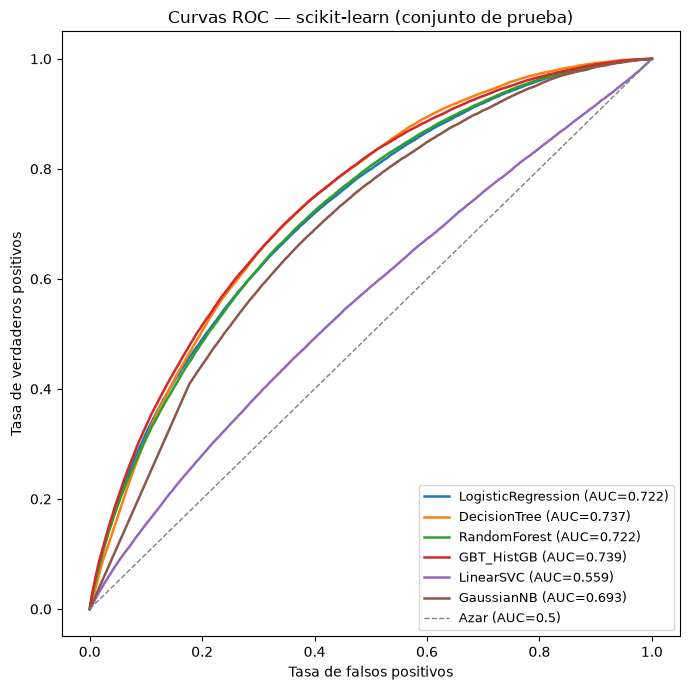

In [3]:
score_cols = {
    "LogisticRegression": "score_LogisticRegression",
    "DecisionTree": "score_DecisionTree",
    "RandomForest": "score_RandomForest",
    "GBT_HistGB": "score_GBT_HistGB",
    "LinearSVC": "score_LinearSVC",
    "GaussianNB": "score_GaussianNB",
}

fig, ax = plt.subplots(figsize=(7,7))
for nombre, col in score_cols.items():
    fpr, tpr, _ = roc_curve(y_test, scores_test[col])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc:.3f})", linewidth=1.8)
ax.plot([0,1],[0,1], linestyle="--", color="gray", linewidth=1, label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC — scikit-learn (conjunto de prueba)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/roc_sklearn.png", dpi=110)
plt.show()


`LinearSVC` es, a simple vista, la única curva que se queda pegada a la diagonal de azar, lo cual es consistente con su AUC de 0,559 y con el diagnóstico de la sección 3.7.

## 3.5. Matrices de confusión (umbral = 0,5)

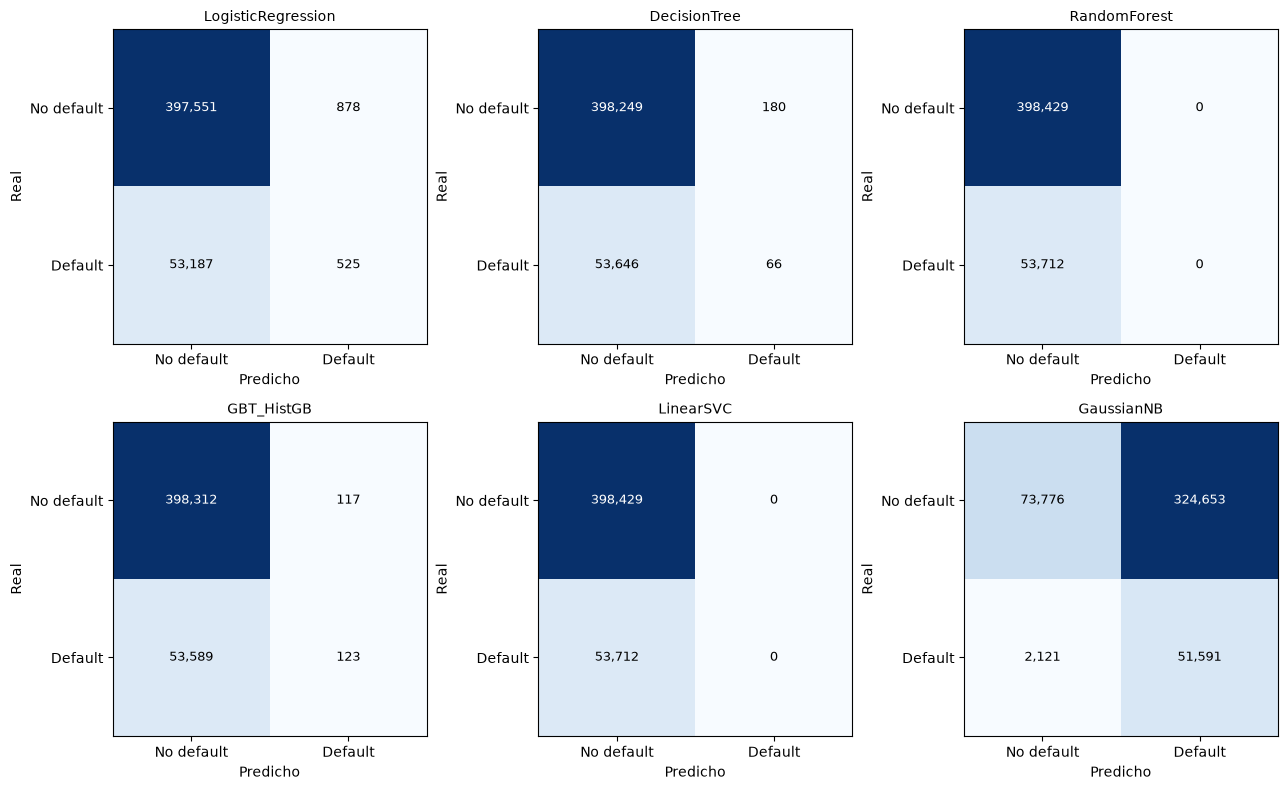

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13,8))
for ax, (nombre, col) in zip(axes.flat, score_cols.items()):
    if nombre == "LinearSVC":
        y_pred = (scores_test[col] >= 0).astype(int)
    else:
        y_pred = (scores_test[col] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=9)
    ax.set_xticks([0,1]); ax.set_xticklabels(["No default","Default"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["No default","Default"])
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/confusion_sklearn.png", dpi=110)
plt.show()


## 3.6. Por qué el F1 es tan bajo: umbral de 0,5 más desbalance de clases

Con solo 11,88% de casos positivos (`default=1`), un modelo puede tener un AUC razonable, es decir, puede ordenar bien los casos de mayor a menor riesgo, y aun así predecir casi nunca \"default\" si se usa un umbral fijo de 0,5 sobre una probabilidad que rara vez supera ese valor cuando la clase minoritaria es tan poco frecuente. Es justo lo que pasa aquí.

In [5]:
resumen_umbral = []
for nombre, col in score_cols.items():
    if nombre == "LinearSVC":
        pred_pos_rate = (scores_test[col] >= 0).mean()
    else:
        pred_pos_rate = (scores_test[col] >= 0.5).mean()
    resumen_umbral.append({"modelo": nombre, "tasa_predicha_positiva": pred_pos_rate})
resumen_umbral = pd.DataFrame(resumen_umbral)
resumen_umbral["tasa_real_positiva"] = y_test.mean()
resumen_umbral.round(4)


,modelo,tasa_predicha_positiva,tasa_real_positiva
0,LogisticRegression,0.0031,0.1188
1,DecisionTree,0.0005,0.1188
2,RandomForest,0.0000,0.1188
3,GBT_HistGB,0.0005,0.1188
4,LinearSVC,0.0000,0.1188
5,GaussianNB,0.8321,0.1188


`RandomForest` y `LinearSVC` predicen 0% de casos positivos en todo el conjunto de prueba (452.141 filas), literalmente nunca cruzan el umbral. `DecisionTree` y `GBT_HistGB` casi nunca lo hacen tampoco (recall menor a 1%). Solo `GaussianNB` predice positivo en una fracción alta de los casos (83%), lo que invierte el problema: gana mucho recall (0,96) pero a costa de una precisión muy baja (0,14) y una exactitud que cae a 27,7%, justo lo contrario de lo que pasa con el resto de los modelos.

Por esta razón el enunciado pide, más adelante, elegir el umbral de clasificación usando solo el conjunto de entrenamiento para la prueba de McNemar, en vez de usar 0,5 sin pensarlo. Con un umbral calibrado al desbalance real, estos mismos modelos se verían mucho más razonables. El AUC, que no depende de ningún umbral, sigue siendo la métrica más útil para comparar modelos en esta sección.

## 3.7. Diagnóstico: el colapso de `LinearSVC`

In [6]:
svc = models_fitted["LinearSVC"]
print("Iteraciones hasta convergencia (n_iter_):", svc.n_iter_, "de max_iter =", svc.max_iter)
print("C seleccionado:", svc.C)
print(f"\nCoeficientes: min={svc.coef_.min():.4g}  max={svc.coef_.max():.4g}  "
      f"media={svc.coef_.mean():.4g}  std={svc.coef_.std():.4g}")
print("Intercepto:", svc.intercept_[0])
print("Coeficientes con valor > 0:", (svc.coef_ > 0).sum(), "de", svc.coef_.shape[1])

score_svc = scores_test["score_LinearSVC"].values
print(f"\ndecision_function en prueba: min={score_svc.min():.6g} max={score_svc.max():.6g} "
      f"media={score_svc.mean():.6g} std={score_svc.std():.4g}")
print("Valores únicos de decision_function:", len(np.unique(score_svc)), "de", len(score_svc))


Iteraciones hasta convergencia (n_iter_): 633 de max_iter = 5000
C seleccionado: 0.05529260848409784

Coeficientes: min=-0.1451  max=3.868e-13  media=-0.02648  std=0.03687
Intercepto: -0.377377377421153
Coeficientes con valor > 0: 11 de 114

decision_function en prueba: min=-1 max=-1 media=-1 std=4.92e-12
Valores únicos de decision_function: 26764 de 452141


El modelo sí convergió (633 iteraciones de un máximo de 5.000, así que no es un problema de falta de iteraciones). El problema está en dónde convergió: prácticamente todos los coeficientes son negativos o básicamente cero, y el puntaje de `decision_function` sobre el conjunto de prueba queda pegado a -1 en el 100% de las filas. En la práctica, el modelo colapsó a un clasificador casi constante que predice \"no default\" para todo el mundo.

¿Por qué pasa esto y no le pasa a la regresión logística con el mismo `C`? La malla de `C` que usamos (con el mismo criterio que la regresión logística) da valores de regularización muy pequeños para un dataset de 1,8 millones de filas, lo que en la práctica equivale a una regularización bastante fuerte. Con la regresión logística, el gradiente sigue empujando el modelo hacia probabilidades informativas incluso con regularización fuerte. Pero con la pérdida hinge de `LinearSVC`, y sin ponderar las clases, el modelo puede cumplir mejor su objetivo simplemente encogiendo los coeficientes hacia cero y dejando que el intercepto diga que no hay default para nadie, en vez de arriesgarse con el 88% de los casos negativos. Es un problema conocido de las SVM sin ponderación de clases sobre datos muy desbalanceados.

Documentamos esto como un hallazgo real del proyecto, no como un error que haya que esconder, porque es justo el tipo de comparación entre librerías que pide la reflexión final: Spark implementa `LinearSVC` con un optimizador distinto (OWL-QN), y queda la pregunta abierta de si mostrará el mismo colapso con la misma malla de `C`.

## 3.8. Costo computacional vs. beneficio

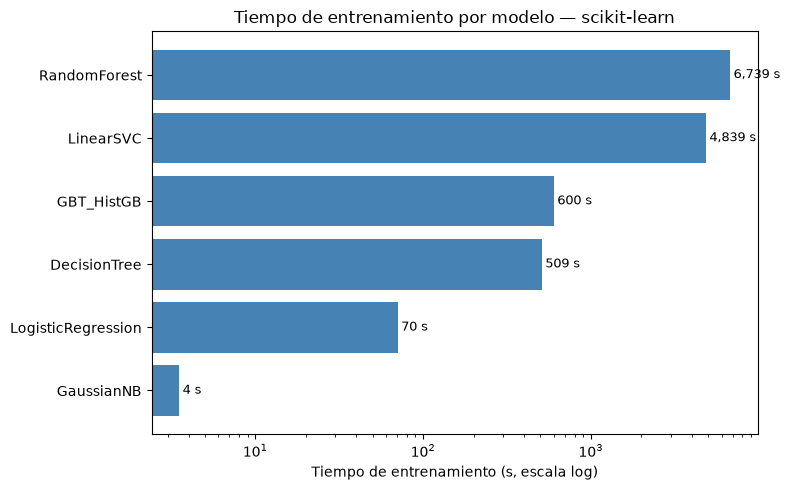

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
orden = tabla.sort_values("tiempo_entrenamiento_s", ascending=True)
bars = ax.barh(orden["modelo"], orden["tiempo_entrenamiento_s"], color="steelblue")
ax.set_xlabel("Tiempo de entrenamiento (s, escala log)")
ax.set_xscale("log")
ax.set_title("Tiempo de entrenamiento por modelo — scikit-learn")
for bar, t in zip(bars, orden["tiempo_entrenamiento_s"]):
    ax.text(bar.get_width()*1.05, bar.get_y()+bar.get_height()/2,
            f"{t:,.0f} s", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/tiempos_sklearn.png", dpi=110)
plt.show()


`RandomForest` (6.739 s) y `LinearSVC` (4.839 s) dominan por completo el tiempo total de cómputo (juntos son más del 96% del tiempo de los 6 modelos), y ninguno de los dos tiene el mejor desempeño: `RandomForest` termina prácticamente empatado con `LogisticRegression`, que tarda casi 100 veces menos (70 segundos), y `LinearSVC` directamente colapsa. En cambio, `HistGradientBoostingClassifier` logra el mejor AUC de los seis modelos (0,739) en solo 600 segundos, menos de una décima parte del tiempo que toma `RandomForest`. Esto nos muestra que, en un dataset de este tamaño y con hardware limitado, un método de boosting basado en histogramas da una mejor relación entre desempeño y costo que el bagging de árboles independientes.

## 3.9. Síntesis: mejor modelo del entorno scikit-learn

Por AUC de prueba, `HistGradientBoostingClassifier` (0,739) es el mejor modelo de este entorno, seguido de cerca por `DecisionTreeClassifier` (0,737). Estos resultados, junto con los puntajes continuos de los 6 modelos que guardamos en `data/sklearn_test_scores.parquet`, son la base de las comparaciones estadísticas de las secciones 5 (DeLong) y 6 (McNemar y bootstrap) más adelante, junto con los resultados que vamos a obtener con PySpark en la siguiente sección.